# Milestone 1 – Terrain Navigation Visualizer

Runs **BFS** and **DFS** on three terrain scenarios and visualises:
- Elevation heat-maps with both paths overlaid
- Side-by-side metric bar charts per scenario
- Summary comparison table across all scenarios

In [8]:
import sys
import os

# When running from terrain_navigation/, the parent dir must be on the path
# so that `import terrain_navigation.*` resolves correctly.
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

from terrain_navigation.scenarios import get_scenario
from terrain_navigation.graph import build_graph
from terrain_navigation.search import bfs, dfs
from terrain_navigation.main import run_algorithm

## Visualisation helpers

In [9]:
def plot_terrain_with_paths(scenario, bfs_result, dfs_result, ax):
    """
    Draw the elevation heat-map for *scenario* on *ax*, then overlay
    the BFS path (solid blue) and DFS path (dashed red).
    Obstacles are masked with a semi-transparent black overlay.
    Start = green circle, Goal = red star.
    """
    terrain   = scenario["terrain"]
    obstacles = scenario["obstacles"]
    start     = scenario["start"]
    goal      = scenario["goal"]

    # ── Elevation base layer ─────────────────────────────────────────────────
    im = ax.imshow(
        terrain,
        cmap="terrain",
        origin="upper",
        aspect="equal",
        interpolation="nearest",
    )
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="Elevation")

    # ── Obstacle overlay ─────────────────────────────────────────────────────
    obstacle_rgba = np.zeros((*terrain.shape, 4))
    obstacle_rgba[obstacles, 3] = 0.75          # alpha only where obstacle
    ax.imshow(obstacle_rgba, origin="upper", aspect="equal", interpolation="nearest")

    # ── Path helper ──────────────────────────────────────────────────────────
    def draw_path(path, color, linestyle, label, zorder):
        if not path:
            return
        rows_seq = [p[0] for p in path]
        cols_seq = [p[1] for p in path]
        ax.plot(
            cols_seq, rows_seq,
            color=color, linestyle=linestyle, linewidth=2.2,
            marker=".", markersize=4, label=label, zorder=zorder,
        )

    draw_path(bfs_result["path"], "#1E88E5", "-",  "BFS", zorder=3)
    draw_path(dfs_result["path"], "#E53935", "--", "DFS", zorder=2)

    # ── Start / Goal markers ─────────────────────────────────────────────────
    ax.plot(start[1], start[0], "o", color="#43A047", markersize=10,
            markeredgecolor="white", markeredgewidth=1.5,
            zorder=5, label="Start")
    ax.plot(goal[1], goal[0],  "*", color="#FF6F00", markersize=14,
            markeredgecolor="white", markeredgewidth=1,
            zorder=5, label="Goal")

    # ── Grid lines aligned to cell boundaries ────────────────────────────────
    rows, cols = terrain.shape
    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.4, alpha=0.5)
    ax.tick_params(which="minor", length=0)

    ax.legend(loc="upper left", fontsize=8, framealpha=0.85)
    ax.set_title(scenario["name"], fontsize=11, fontweight="bold")
    ax.set_xlabel("col", fontsize=8)
    ax.set_ylabel("row", fontsize=8)
    ax.tick_params(labelsize=7)


def plot_metrics_bar(bfs_result, dfs_result, ax):
    """
    Draw a grouped bar chart comparing BFS vs DFS on three metrics:
    path length, weighted path cost, and nodes explored.
    """
    metrics = ["path_length", "weighted_path_cost", "nodes_explored"]
    labels  = ["Path length\n(steps)", "Weighted\ncost", "Nodes\nexplored"]

    bfs_vals = [bfs_result.get(m, 0) for m in metrics]
    dfs_vals = [dfs_result.get(m, 0) for m in metrics]

    x     = np.arange(len(metrics))
    width = 0.35

    bars_bfs = ax.bar(x - width / 2, bfs_vals, width,
                      color="#1E88E5", label="BFS", alpha=0.88)
    bars_dfs = ax.bar(x + width / 2, dfs_vals, width,
                      color="#E53935", label="DFS", alpha=0.88)

    for bar in list(bars_bfs) + list(bars_dfs):
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, h * 1.01,
            f"{h:.0f}",
            ha="center", va="bottom", fontsize=7,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("Value", fontsize=8)
    ax.set_title("BFS vs DFS – Metrics", fontsize=10)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)

## Run all three scenarios

In [10]:
SCENARIO_NAMES = ["flat_terrain", "mountain_barrier", "random_terrain"]

all_results = {}
for name in SCENARIO_NAMES:
    scenario = get_scenario(name)
    graph    = build_graph(scenario["terrain"], scenario["obstacles"])
    bfs_r    = run_algorithm(bfs, graph, scenario["terrain"], scenario["start"], scenario["goal"])
    dfs_r    = run_algorithm(dfs, graph, scenario["terrain"], scenario["start"], scenario["goal"])
    all_results[name] = {"scenario": scenario, "bfs": bfs_r, "dfs": dfs_r}
    print(f"{name:20s}  BFS path={bfs_r['path_length']:4d} steps  DFS path={dfs_r['path_length']:4d} steps")

flat_terrain          BFS path=  48 steps  DFS path= 336 steps
mountain_barrier      BFS path=  40 steps  DFS path= 296 steps
random_terrain        BFS path=  48 steps  DFS path= 192 steps


---
## Scenario 1 – Flat Terrain

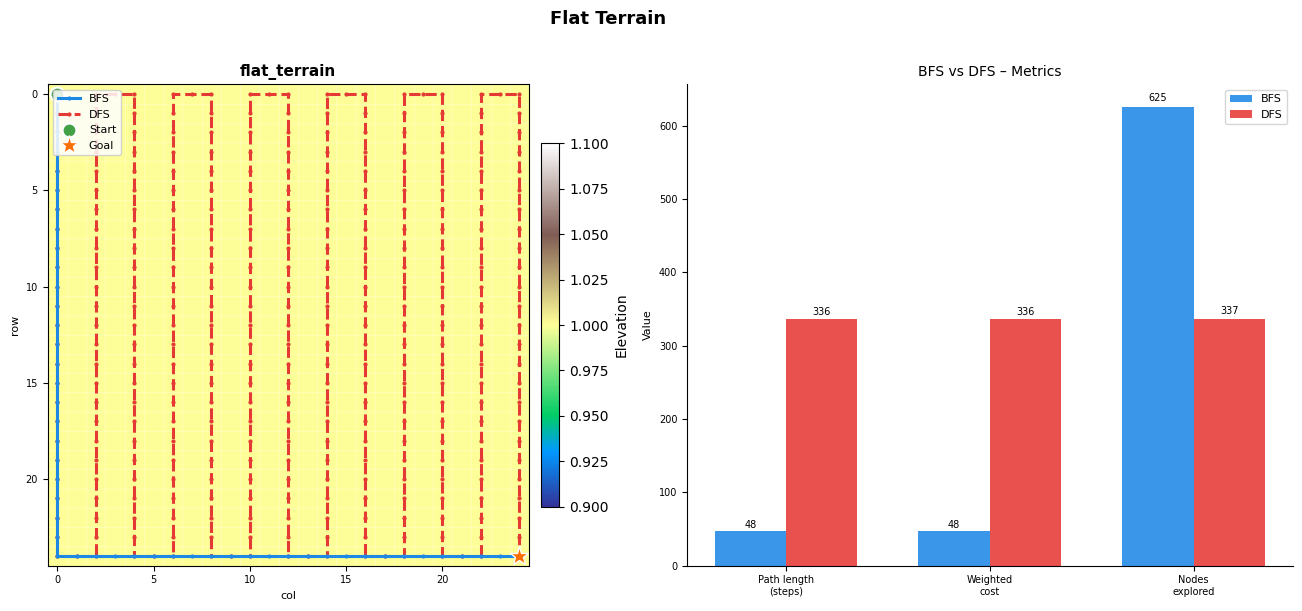

In [11]:
entry = all_results["flat_terrain"]

fig, (ax_map, ax_bar) = plt.subplots(1, 2, figsize=(14, 6))
plot_terrain_with_paths(entry["scenario"], entry["bfs"], entry["dfs"], ax_map)
plot_metrics_bar(entry["bfs"], entry["dfs"], ax_bar)
fig.suptitle("Flat Terrain", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## Scenario 2 – Mountain Barrier

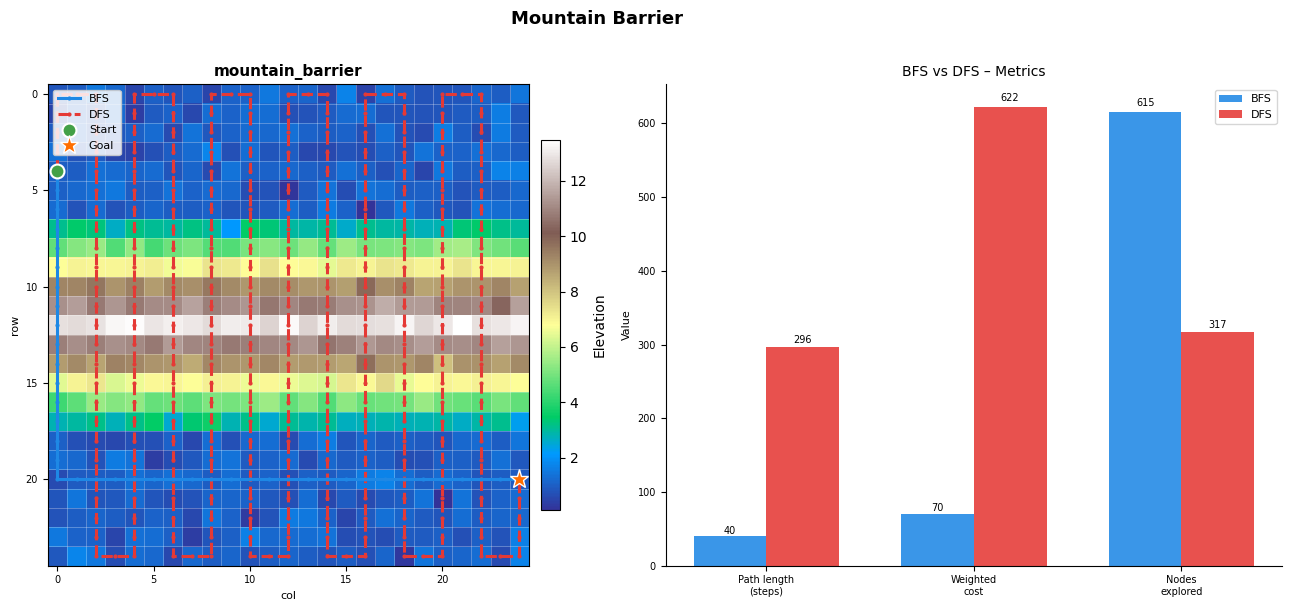

In [12]:
entry = all_results["mountain_barrier"]

fig, (ax_map, ax_bar) = plt.subplots(1, 2, figsize=(14, 6))
plot_terrain_with_paths(entry["scenario"], entry["bfs"], entry["dfs"], ax_map)
plot_metrics_bar(entry["bfs"], entry["dfs"], ax_bar)
fig.suptitle("Mountain Barrier", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## Scenario 3 – Random Terrain

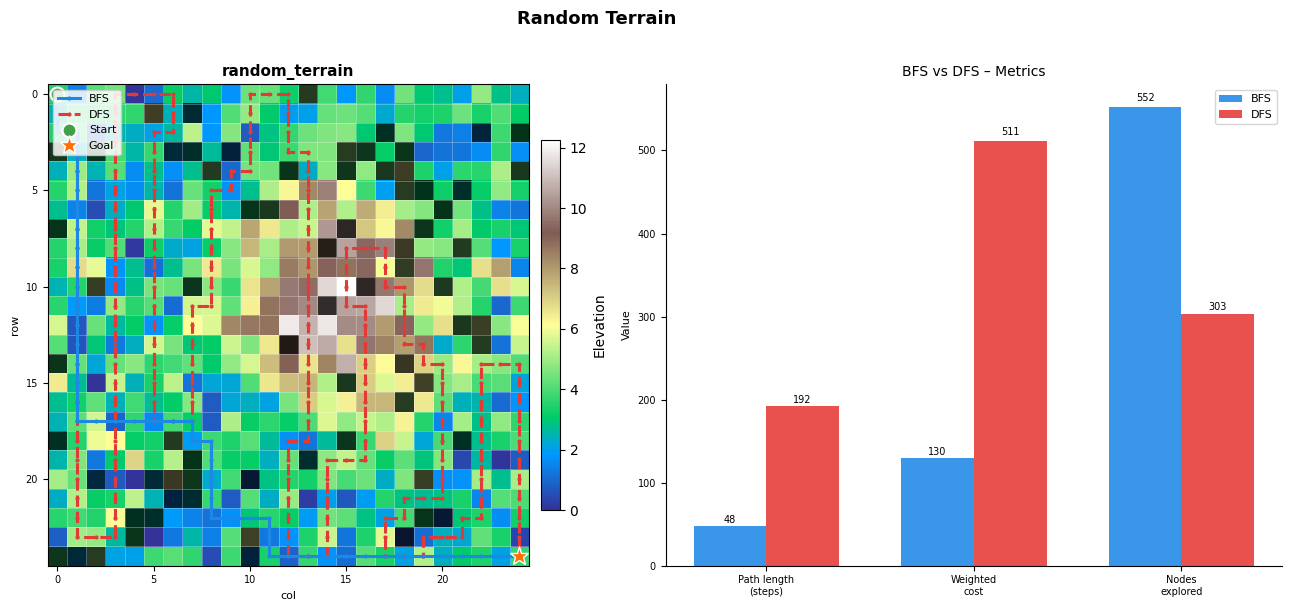

In [13]:
entry = all_results["random_terrain"]

fig, (ax_map, ax_bar) = plt.subplots(1, 2, figsize=(14, 6))
plot_terrain_with_paths(entry["scenario"], entry["bfs"], entry["dfs"], ax_map)
plot_metrics_bar(entry["bfs"], entry["dfs"], ax_bar)
fig.suptitle("Random Terrain", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## Summary – All Scenarios × Both Algorithms

In [14]:
header = f"{'Scenario':<22} {'Algo':<6} {'Path len':>9} {'Wtd cost':>10} {'Elev gain':>10} {'Nodes exp':>10} {'Runtime(s)':>11}"
print(header)
print("-" * len(header))

for name in SCENARIO_NAMES:
    for algo_key, label in [("bfs", "BFS"), ("dfs", "DFS")]:
        r = all_results[name][algo_key]
        print(
            f"{name:<22} {label:<6}"
            f"{r['path_length']:>9}"
            f"{r['weighted_path_cost']:>10.2f}"
            f"{r['elevation_gain']:>10.2f}"
            f"{r['nodes_explored']:>10}"
            f"{r['runtime_seconds']:>11.6f}"
        )
    print()

Scenario               Algo    Path len   Wtd cost  Elev gain  Nodes exp  Runtime(s)
------------------------------------------------------------------------------------
flat_terrain           BFS          48     48.00      0.00       625   0.000750
flat_terrain           DFS         336    336.00      0.00       337   0.000434

mountain_barrier       BFS          40     70.24     15.10       615   0.000538
mountain_barrier       DFS         296    621.84    162.90       317   0.000297

random_terrain         BFS          48    130.13     41.19       552   0.000458
random_terrain         DFS         192    510.81    159.53       303   0.000304

